# HPS v2

The introduction and implementations of HPS v2.

Written by Junkun Yuan (yuanjk0921@outlook.com).

Last updated on June 17, 2025; &nbsp; First committed on March 7, 2025.

See more reading papers and notes [here](https://junkunyuan.github.io/reading_papers/reading_papers.html).

**References**

- [**Human Preference Score v2: A Solid Benchmark for Evaluating Human Preferences of Text-to-Image Synthesis** *(arXiv 2023)*](https://arxiv.org/pdf/2306.09341): The paper which proposes the HPS v2.

**Contents**
- HPS v2
- Implementations

## HPS v2

HPD v2 comprises 798090 human preference choices on 433760 pairs of images.

HPS v2 uses HPD v2 to fine-tune CLIP for *image generation* evaluation.

## Implementations

In [ ]:
## --------------------------------------------------------------------------------
## Prepare data
## --------------------------------------------------------------------------------
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class ImageDataset(Dataset):
    def __init__(self, image_paths, prompts, image_size):
        self.image_paths = image_paths
        self.prompts = prompts
        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        file_path = self.image_paths[index]
        image = self.transform(Image.open(file_path))
        prompt = self.prompts[index]
        return image, prompt, file_path

## Create a noise image
noise = np.random.randint(0, 256, (3, 224, 224), dtype=np.uint8)
image = Image.fromarray(noise, mode='RGB')
image.save("random_noise.png")

## Build toy data for evaluation
image_paths = ["0.png"] * 8
image_paths += ["1.png"] * 8
image_paths = image_paths + ["random_noise.png"] * 2

prompts = [
    "a bench and a bowl",  # 1
    "a bench and a bird",  # 2
    "a green bench and a blue bowl",  # 3
    "a blue bench and a green bowl",  # 4
    "a bench is on the left of a bowl",  # 5
    "a bowl is on the left of a bench",  # 6
    "Items are neatly arranged in the room.",  # 7
    "Under the blue sky and white clouds, the wind blows the grassland.",  # 8
    "two bears",  # 9
    "a bear and a bear",  # 10
    "a bear and a beer",  # 11
    "a bear is reading books",  # 12
    "two bears are reading books",  # 13
    "three bears are reading books",  # 14
    "A warm family",  # 15
    "A beautiful natural scenery",  # 16
    "two bears",  # 17
    "a bear and a bear"  # 18
]

dataset = ImageDataset(image_paths=image_paths, prompts=prompts, image_size=256)
dataloader = DataLoader(dataset=dataset, batch_size=8, shuffle=False)

In [ ]:
## python -m pip install hpsv2
import hpsv2

## Download checkpoints first
## HPS v2: https://huggingface.co/spaces/xswu/HPSv2/resolve/main/HPS_v2_compressed.pt
## HPS v2.1: https://huggingface.co/xswu/HPSv2/tree/main

model_path = "xswu-HPSv2/HPS_v2.1_compressed.pt"
model, _, _, preprocess_val_on_tensor, tokenizer = hpsv2.initialize_model(model_path, "cuda")

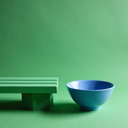

=> prompt: a bench and a bowl, Score: 0.261474609375
=> prompt: a bench and a bird, Score: 0.18115234375
=> prompt: a green bench and a blue bowl, Score: 0.291015625
=> prompt: a blue bench and a green bowl, Score: 0.293701171875
=> prompt: a bench is on the left of a bowl, Score: 0.2408447265625
=> prompt: a bowl is on the left of a bench, Score: 0.23828125
=> prompt: Items are neatly arranged in the room., Score: 0.153076171875
=> prompt: Under the blue sky and white clouds, the wind blows the grassland., Score: 0.11370849609375


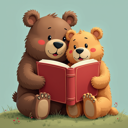

=> prompt: two bears, Score: 0.325439453125
=> prompt: a bear and a bear, Score: 0.315673828125
=> prompt: a bear and a beer, Score: 0.234130859375
=> prompt: a bear is reading books, Score: 0.2958984375
=> prompt: two bears are reading books, Score: 0.34716796875
=> prompt: three bears are reading books, Score: 0.296630859375
=> prompt: A warm family, Score: 0.2371826171875
=> prompt: A beautiful natural scenery, Score: 0.162109375


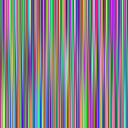

=> prompt: two bears, Score: 0.16845703125
=> prompt: a bear and a bear, Score: 0.156982421875


In [ ]:
## --------------------------------------------------------------------------------
## Evaluate
## --------------------------------------------------------------------------------
for idx, (images, prompts, file_paths) in enumerate(dataloader):
    scores = hpsv2.batch_score(model, preprocess_val_on_tensor, tokenizer, images, prompts, device="cuda")
        
    ## Show results
    image = Image.open(file_paths[0]).resize((128, 128))
    display(image)
    for prompt, score in zip(prompts, scores):
        print(f"=> prompt: {prompt}, Score: {score}")

**Observations:**

From the perspective of semantic alignment evaluation, it is good at identifying <font color=red>objects</font> & <font color=red>numeracy</font>, but <font color=red>insensitive</font> to <font color=red>color</font> & <font color=red>global description</font> & <font color=red>spatial relationship</font>.